In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
os.environ["PATH"] += ":/usr/local/bin"
from pathlib import Path

import pandas as pd
import pypangraph as pp
from junction_analysis import pangraph_utils as pu

import plotly.io as pio
pio.renderers.default = "browser" 

from Bio import Phylo

from junction_analysis.consensus import build_edge_index, encode_edge_paths_binary, fitch_ancestral_reconstruction, filter_paths_by_edge_presence, compute_majority_path, consensus_paths_and_assignments, deduplicate_blocks_by_sequence, filter_isolates_by_anchor_count, rededuplicate_cluster_paths, find_consensus_paths_refined, build_block_index, decide_ambiguities, encode_paths_binary, filter_deduplicated_paths, remap_consensus_to_global_contexts, create_block_msas_for_cluster, summarize_block_msas, collect_all_block_branch_lengths
from junction_analysis.plotting import plot_junction_pangraph_interactive, plot_all_junctions_pairwise_distances_zoom, plot_event_tree
from junction_analysis.helpers import build_subtree
from junction_analysis.consensus import find_consensus_paths_core, cluster_map_to_dataframe, save_consensus_cache, cluster_isolates_by_core_blocks, cluster_tree_by_branch_length
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries, summarize_inversions_consensus, summarize_translocations_consensus, write_insertions_fasta, load_all_insertions_summaries, load_all_inversions_summaries, load_all_translocations_summaries, summarize_ambiguous_insertions, load_all_ambiguous_insertions_summaries, detect_event_blocks, group_events_by_clade, find_combined_events, combine_all_junctions_summaries, deduplicate_events

In [2]:
jdf_all = pd.read_csv("../results/junction_summary_df.csv")
jdf_all

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,mean_length_translocation,mean_length_inversion,mean_event_length,block_ji_dist,edge_ji_dist,has_singleton_gain,has_singleton_loss,singleton_gain_isolate,singleton_loss_isolate,singleton_has_own_cluster
0,HUTOPWFGVH_f__WJBYSSJHSE_f,222,5,False,3,218,False,0.100354,11,18176,...,0.0,0.0,744.000000,0.991064,0.973218,NaN,NaN,NaN,NaN,NaN
1,IZQZNHJQRQ_f__ZVPGGEJIIF_f,222,3,False,2,221,True,0.028831,5,11739,...,0.0,0.0,777.000000,0.996997,0.990991,True,False,NZ_CP051615.1,NaN,False
2,JNLRGIQXOF_f__YQUHGDANHE_f,222,3,False,2,221,True,0.028831,5,27949,...,0.0,0.0,1437.000000,0.996997,0.990991,True,False,NZ_AP022362.1,NaN,False
3,JMOMDSHCBS_r__SPDPCYMYDN_r,222,3,False,2,220,False,0.051397,5,7364,...,0.0,0.0,777.000000,0.994021,0.982064,NaN,NaN,NaN,NaN,NaN
4,JKRDVEYDGL_f__OTPJRRWJRK_f,222,3,False,2,221,True,0.028831,5,10056,...,0.0,0.0,38175.000000,0.996997,0.990991,True,False,NZ_CP032201.1,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,PLTCZQCVRD_f__RYYAQMEJGY_f,3,48,True,3,1,False,1.098612,80,101503,...,3366.0,0.0,7118.870968,0.138971,0.058489,NaN,NaN,NaN,NaN,NaN
514,DSLXSJZSTL_r__KGJXRPELGX_f,2,7,True,2,1,True,0.693147,20,17091,...,0.0,0.0,3420.000000,0.818182,0.800000,NaN,NaN,NaN,NaN,NaN
515,GPXHVRRZLC_f__KYQOKYBCOW_f,2,8,False,2,1,True,0.693147,12,65779,...,0.0,0.0,0.000000,0.500000,0.000000,NaN,NaN,NaN,NaN,NaN
516,XXIWNZXZTK_f__ZLAJFQLBFQ_r,2,3,False,2,1,True,0.693147,6,83629,...,0.0,0.0,0.000000,0.500000,0.000000,NaN,NaN,NaN,NaN,NaN


## Try new single block event detection

In [8]:
junction_name = "JVNRLCFAVD_f__PLTCZQCVRD_r"
pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_name}.json")
tree_path = "../config/polished_tree.nwk"

cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, *_ = find_consensus_paths_refined(
            junction_name,
            clustering_bl_thresh=0.001,
            tree_path=str(tree_path),
            rare_context_thresh=0.2, z_score_threshold=3.5, seq_dedup_length_threshold=0.05
        )

for i in range(1, len(consensus_paths_plotting) + 1):
    isolates_1 = assignment_df_plotting[assignment_df_plotting['best_consensus'] == f"consensus_{i}"].index.tolist()
    deduplicated_paths = {iso: path for iso, path in path_dict.items() if iso in isolates_1}
    df, path_dict_annotated, consensus_annotated = detect_event_blocks(deduplicated_paths, consensus_paths_plotting[i-1])
    deduplicated_df, path_dict_annotated = group_events_by_clade(df, path_dict_annotated, isolates_1, method="fitch")
    insertions, deletions, inversions = find_combined_events(path_dict_annotated, consensus_annotated, tree_path, isolates_1)
    insertions_df = write_insertions_fasta(junction_name, pangraph, insertions, consensus = i, save_df=True, parent_dir = "../results/atb_lookup_new/insertions")
    inversions_df = summarize_inversions_consensus(inversions, junction_name, pangraph, consensus_id = i, parent_dir = "../results/atb_lookup_new/inversions", save_df=True)
    deletions_df = summarize_deletions_consensus(deletions, junction_name, pangraph, path_dict_annotated, assignment_df_plotting, consensus_id=i, parent_dir = "../results/atb_lookup_new/deletions", rerun_alignment=False, save_df=True)
    break

insertions_df = load_all_insertions_summaries("../results/atb_lookup_new/insertions", junction_name, save_df=True)
inversions_df = load_all_inversions_summaries("../results/atb_lookup_new/inversions", junction_name, save_df=True)
deletions_df = load_all_deletions_summaries("../results/atb_lookup_new/deletions", junction_name, save_df=True)

Skipping core: FASTA, alignment and tree already exist in /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/consensus_analysis/JVNRLCFAVD_f__PLTCZQCVRD_r
No ambiguous blocks.
152 / 166 isolates share the majority path
No ambiguous blocks.
48 / 52 isolates share the majority path
No inversions found for consensus_1, nothing saved.


In [5]:
summaries = combine_all_junctions_summaries("../results/atb_lookup_new", save_df=True)
deduplicated_events_df = deduplicate_events(summaries, save_path="../results/atb_lookup_new/deduplicated_events.csv")  

Saved insertions summary to ../results/atb_lookup_new/insertions/all_junctions_insertions.csv
No ambiguous_insertions found across any junction.
Saved deletions summary to ../results/atb_lookup_new/deletions/all_junctions_deletions.csv
No translocations directory found at ../results/atb_lookup_new/translocations, skipping.
Saved inversions summary to ../results/atb_lookup_new/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup_new/deduplicated_events.csv


In [9]:
df

,event_type,isolate,block_id,strand,context,nid
0,insertion,NZ_CP107178.1,13215584309532095468,True,11857430741748229553_1,3814848884895684720
1,insertion,NZ_CP107178.1,299597556374749924,True,11857430741748229553_1,13098886026569365312
2,insertion,NZ_CP107178.1,3044131756871666354,True,11857430741748229553_1,13805386263192168331
3,insertion,NZ_CP107178.1,4693847346091695808,True,11857430741748229553_1,18095386813531296429
4,insertion,NZ_CP107178.1,855578315155134938,True,11857430741748229553_1,4019237150090760928
...,...,...,...,...,...,...
5091,insertion,NZ_CP089445.1,11576636328280974133,True,11857430741748229553_1,12896238817875128271
5092,insertion,NZ_CP089445.1,4318609433926384500,True,11857430741748229553_1,12541722387042603920
5093,insertion,NZ_CP089445.1,2333889656097886015,True,11857430741748229553_1,2497978079440439963
5094,insertion,NZ_CP089445.1,6643136935133510555,True,11857430741748229553_1,17567171235955656051


In [6]:
deduplicated_events_df[(deduplicated_events_df['junction_name'] == junction_name) & (deduplicated_events_df['event_type'] == "insertion") & (deduplicated_events_df['consensus'] == "consensus_1")]

,event_type,junction_name,consensus,path,parent_clade_id,insertion,fasta_path,length,strand,start_pos,end_pos,isolates,deletion,consensus_sequence,position,inversion
143,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_1,[10068629200564038664|+|4008710015796947830]_[...,NODE_00001400.92,segment_10,../results/atb_lookup_new/insertions/JVNRLCFAV...,7523,+,85636.0,110969.0,"[NZ_CP107178.1, NZ_CP115324.1, NZ_CP124353.1, ...",NaN,NaN,NaN,NaN
144,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_1,[10068629200564038664|+|4008710015796947830]_[...,NZ_CP089445.1,segment_1,../results/atb_lookup_new/insertions/JVNRLCFAV...,25337,+,46291.0,71628.0,[NZ_CP089445.1],NaN,NaN,NaN,NaN
145,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_1,[10421491611936560995|+|17892350302300920238],NZ_CP107120.1,segment_10,../results/atb_lookup_new/insertions/JVNRLCFAV...,386,+,142057.0,142472.0,[NZ_CP107120.1],NaN,NaN,NaN,NaN
146,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_1,[10421491611936560995|+|17892350302300920238],NZ_CP107162.1,segment_10,../results/atb_lookup_new/insertions/JVNRLCFAV...,392,+,48378.0,48824.0,[NZ_CP107162.1],NaN,NaN,NaN,NaN
147,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_1,[10421491611936560995|+|17892350302300920238],NZ_CP124367.1,segment_4,../results/atb_lookup_new/insertions/JVNRLCFAV...,346,+,57878.0,58282.0,[NZ_CP124367.1],NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_1,[8904217446417595038|+|5405288517967012958],NODE_00001810.99,segment_7,../results/atb_lookup_new/insertions/JVNRLCFAV...,226,+,45773.0,46051.0,[NZ_CP107122.1],NaN,NaN,NaN,NaN
342,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_1,[9040145740657345147|+|419910524912450372_23],NZ_CP107128.1,segment_0,../results/atb_lookup_new/insertions/JVNRLCFAV...,4869,+,33982.0,38851.0,[NZ_CP107128.1],NaN,NaN,NaN,NaN
343,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_1,[9349187549610209210|+|17460835948606006684]_[...,NODE_00001840.97,segment_16,../results/atb_lookup_new/insertions/JVNRLCFAV...,3614,+,127596.0,131210.0,[NZ_CP082831.1],NaN,NaN,NaN,NaN
344,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_1,[9349187549610209210|+|17460835948606006684]_[...,NODE_00001840.97,segment_6,../results/atb_lookup_new/insertions/JVNRLCFAV...,30278,+,46590.0,76868.0,"[NZ_CP107178.1, NZ_CP115324.1, NZ_CP124353.1, ...",NaN,NaN,NaN,NaN


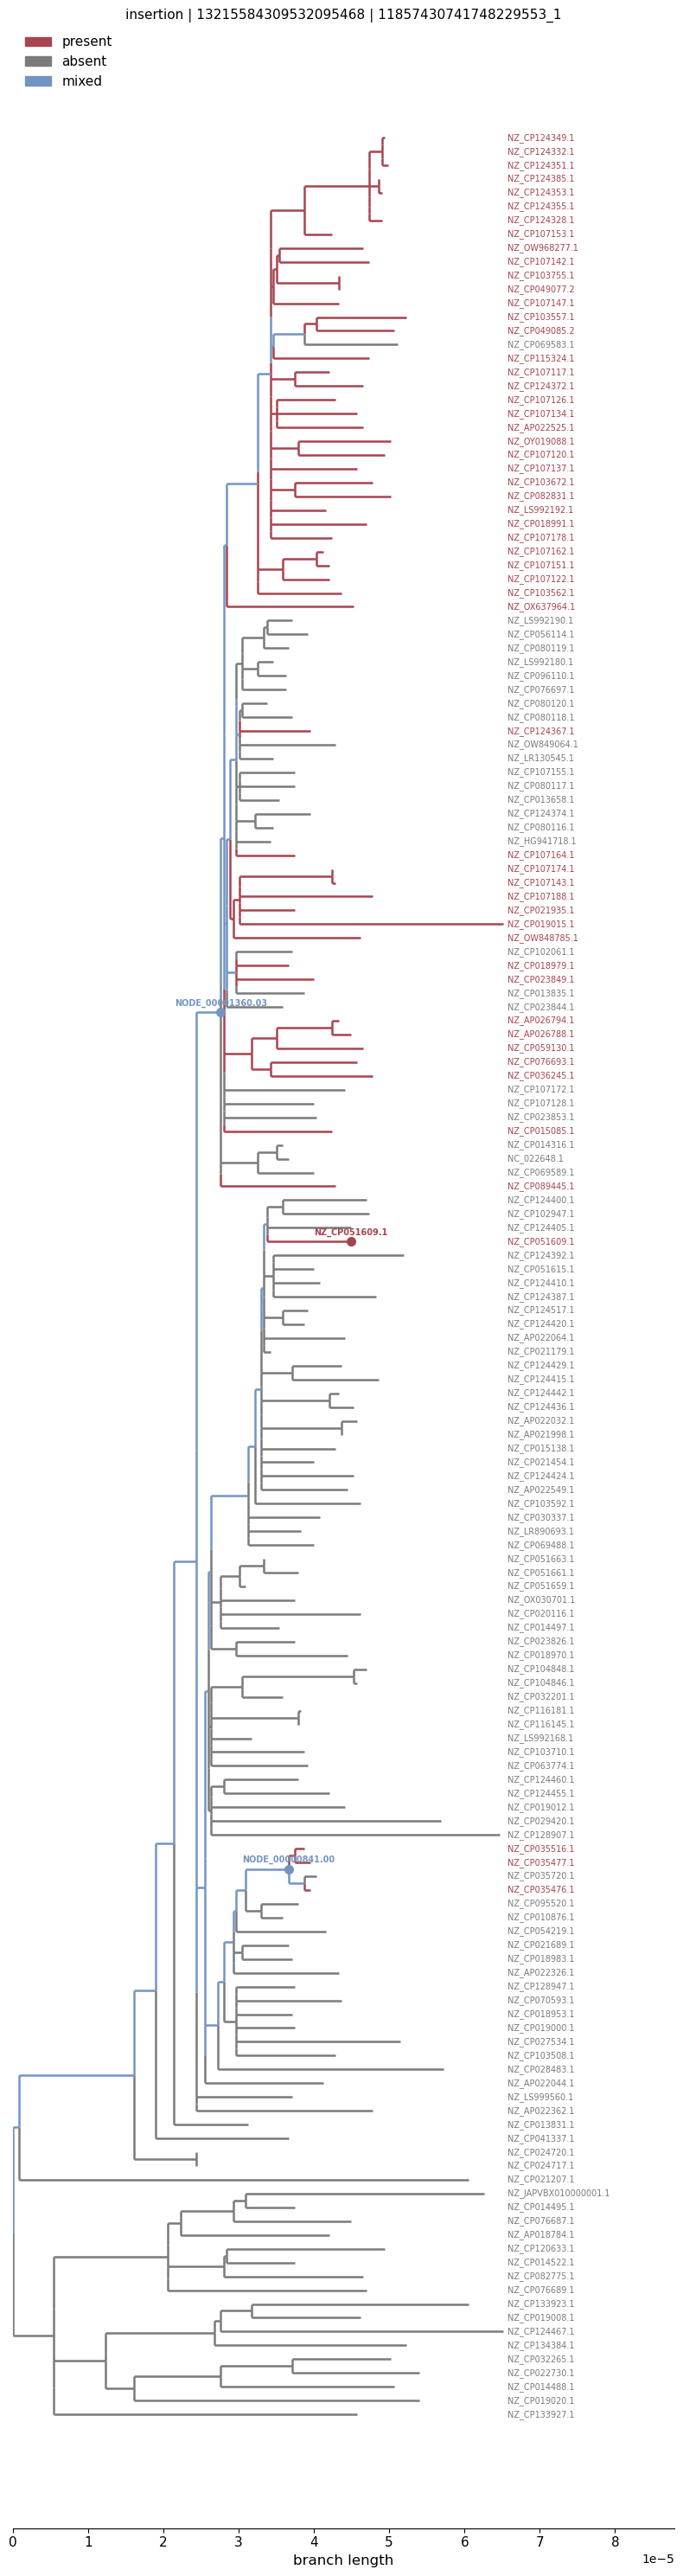

In [10]:
plot_event_tree(
      df,
      isolates_1,
      block_id=13215584309532095468,
      event_type="insertion",
      context="11857430741748229553_1",
      clade_df=deduplicated_df,
  )

In [4]:
deduplicated_events_df[(deduplicated_events_df['event_type'] == 'insertion') & (deduplicated_events_df['junction_name'] == "JVNRLCFAVD_f__PLTCZQCVRD_r") & (deduplicated_events_df['consensus'] == "consensus_2")]

,event_type,junction_name,consensus,path,parent_clade_id,insertion,fasta_path,length,strand,start_pos,end_pos,isolates,deletion,consensus_sequence,position,inversion
232,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_2,[10421491611936560995|+|11857430741748229553_1...,NODE_00000321.00,segment_5,../results/atb_lookup_new/insertions/JVNRLCFAV...,886,+,110455.0,111341.0,"[NZ_CP124506.1, NZ_CP124359.1, NZ_CP124337.1, ...",NaN,NaN,NaN,NaN
233,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_2,[11653701223447733587|+|11857430741748229553_1...,NODE_00000321.00,segment_1,../results/atb_lookup_new/insertions/JVNRLCFAV...,66694,+,12254.0,79040.0,"[NZ_CP124506.1, NZ_CP124359.1, NZ_CP124337.1, ...",NaN,NaN,NaN,NaN
234,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_2,[12548330780063276704|+|11857430741748229553_1...,NODE_00000321.00,segment_2,../results/atb_lookup_new/insertions/JVNRLCFAV...,886,+,79874.0,80760.0,"[NZ_CP124506.1, NZ_CP124359.1, NZ_CP124337.1, ...",NaN,NaN,NaN,NaN
235,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_2,[12683065985133529193|+|10118819150613450362_14],NZ_CP063515.1,segment_0,../results/atb_lookup_new/insertions/JVNRLCFAV...,711,+,22415.0,23126.0,[NZ_CP063515.1],NaN,NaN,NaN,NaN
236,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_2,[13215584309532095468|+|11857430741748229553_1...,NODE_00000261.00,segment_0,../results/atb_lookup_new/insertions/JVNRLCFAV...,68010,+,5090.0,73616.0,"[NZ_CP124500.1, NZ_CP124320.1, NZ_CP124498.1]",NaN,NaN,NaN,NaN
237,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_2,[13215584309532095468|+|11857430741748229553_1...,NODE_00000170.89,segment_9,../results/atb_lookup_new/insertions/JVNRLCFAV...,14918,+,5090.0,121069.0,"[NZ_CP124506.1, NZ_CP124359.1, NZ_CP124337.1, ...",NaN,NaN,NaN,NaN
238,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_2,[13600423774195923952|+|11857430741748229553_1],NODE_00000321.00,segment_3,../results/atb_lookup_new/insertions/JVNRLCFAV...,110,+,82057.0,82167.0,"[NZ_CP124506.1, NZ_CP124359.1, NZ_CP124337.1, ...",NaN,NaN,NaN,NaN
239,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_2,[1625051445738839389|+|11857430741748229553_1],NODE_00000321.00,segment_7,../results/atb_lookup_new/insertions/JVNRLCFAV...,379,+,119346.0,119725.0,"[NZ_CP124506.1, NZ_CP124359.1, NZ_CP124337.1, ...",NaN,NaN,NaN,NaN
240,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_2,[299597556374749924|+|11857430741748229553_1]_...,NODE_00000321.00,segment_0,../results/atb_lookup_new/insertions/JVNRLCFAV...,4091,+,6427.0,10522.0,"[NZ_CP124506.1, NZ_CP124359.1, NZ_CP124337.1, ...",NaN,NaN,NaN,NaN
241,insertion,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_2,[3790346889857029618|-|12748501975230674832_8],NZ_CP098219.1,segment_0,../results/atb_lookup_new/insertions/JVNRLCFAV...,1336,-,14935.0,16271.0,[NZ_CP098219.1],NaN,NaN,NaN,NaN


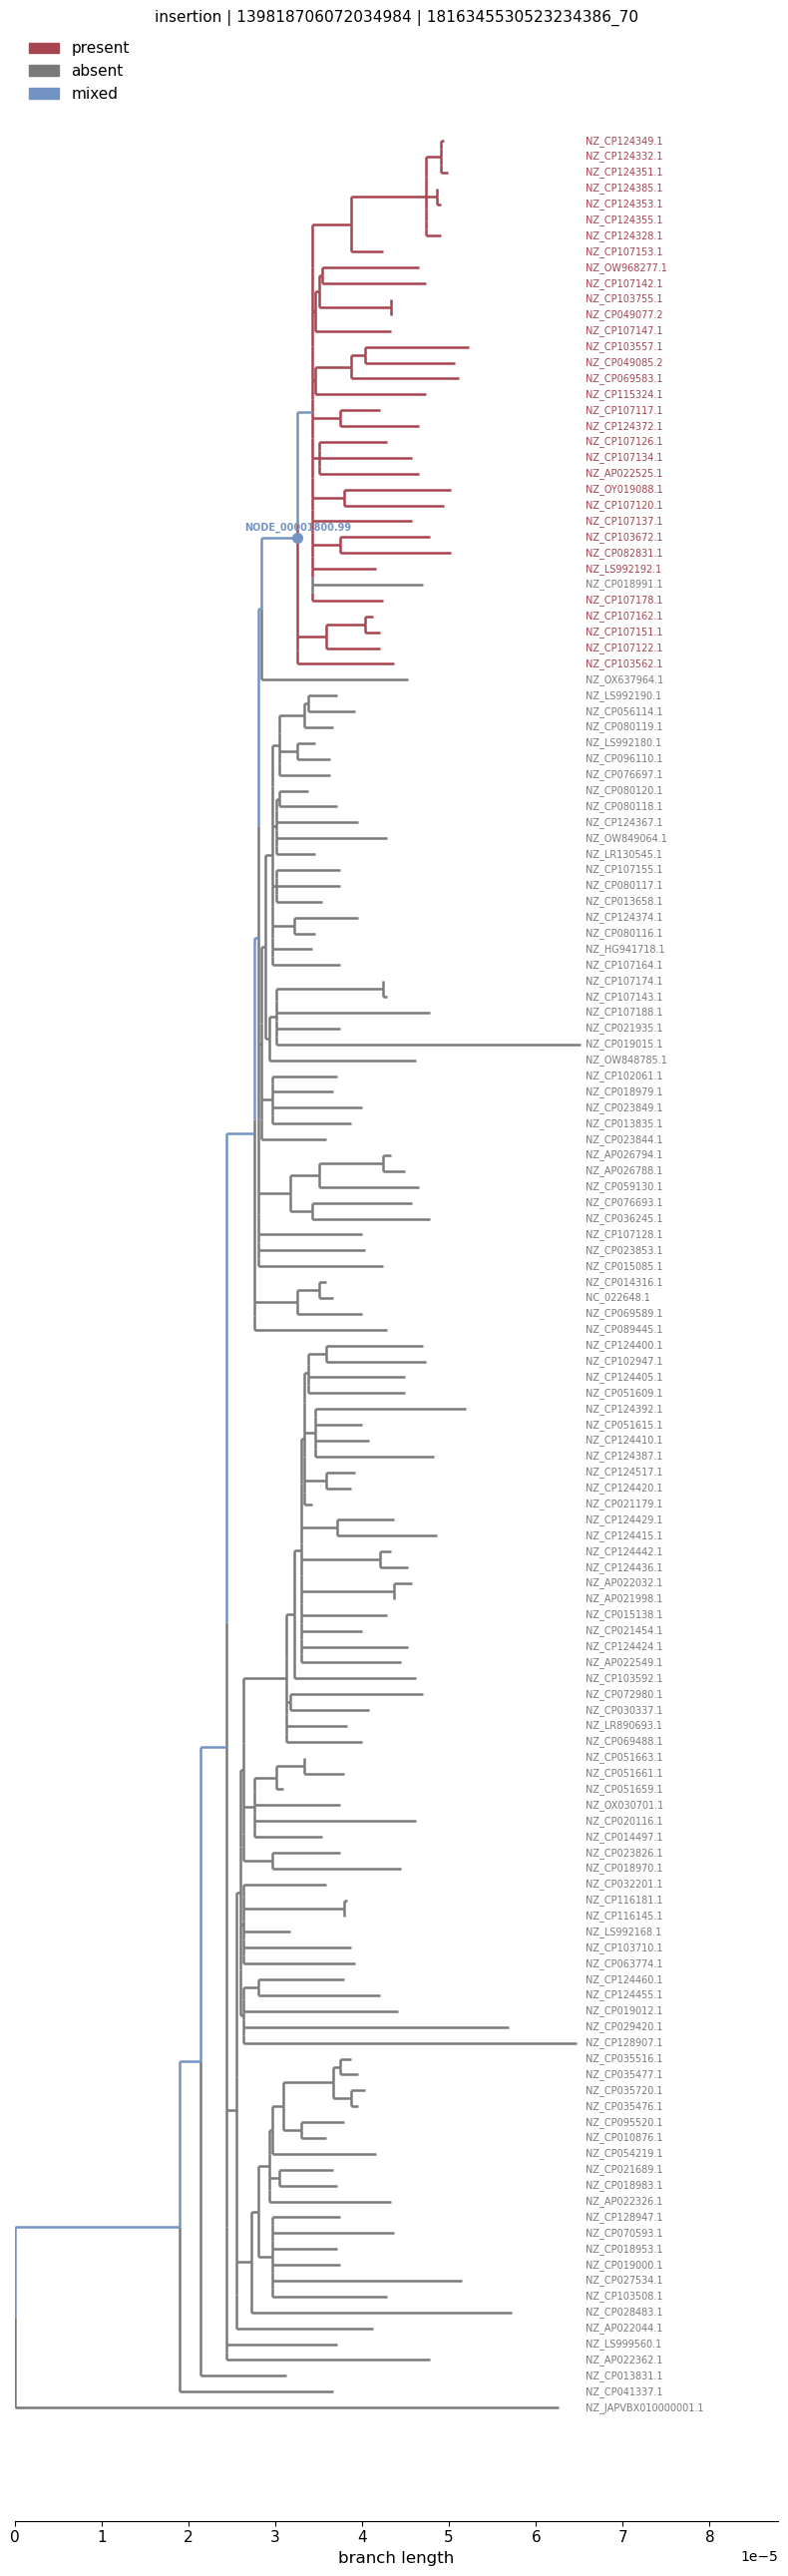

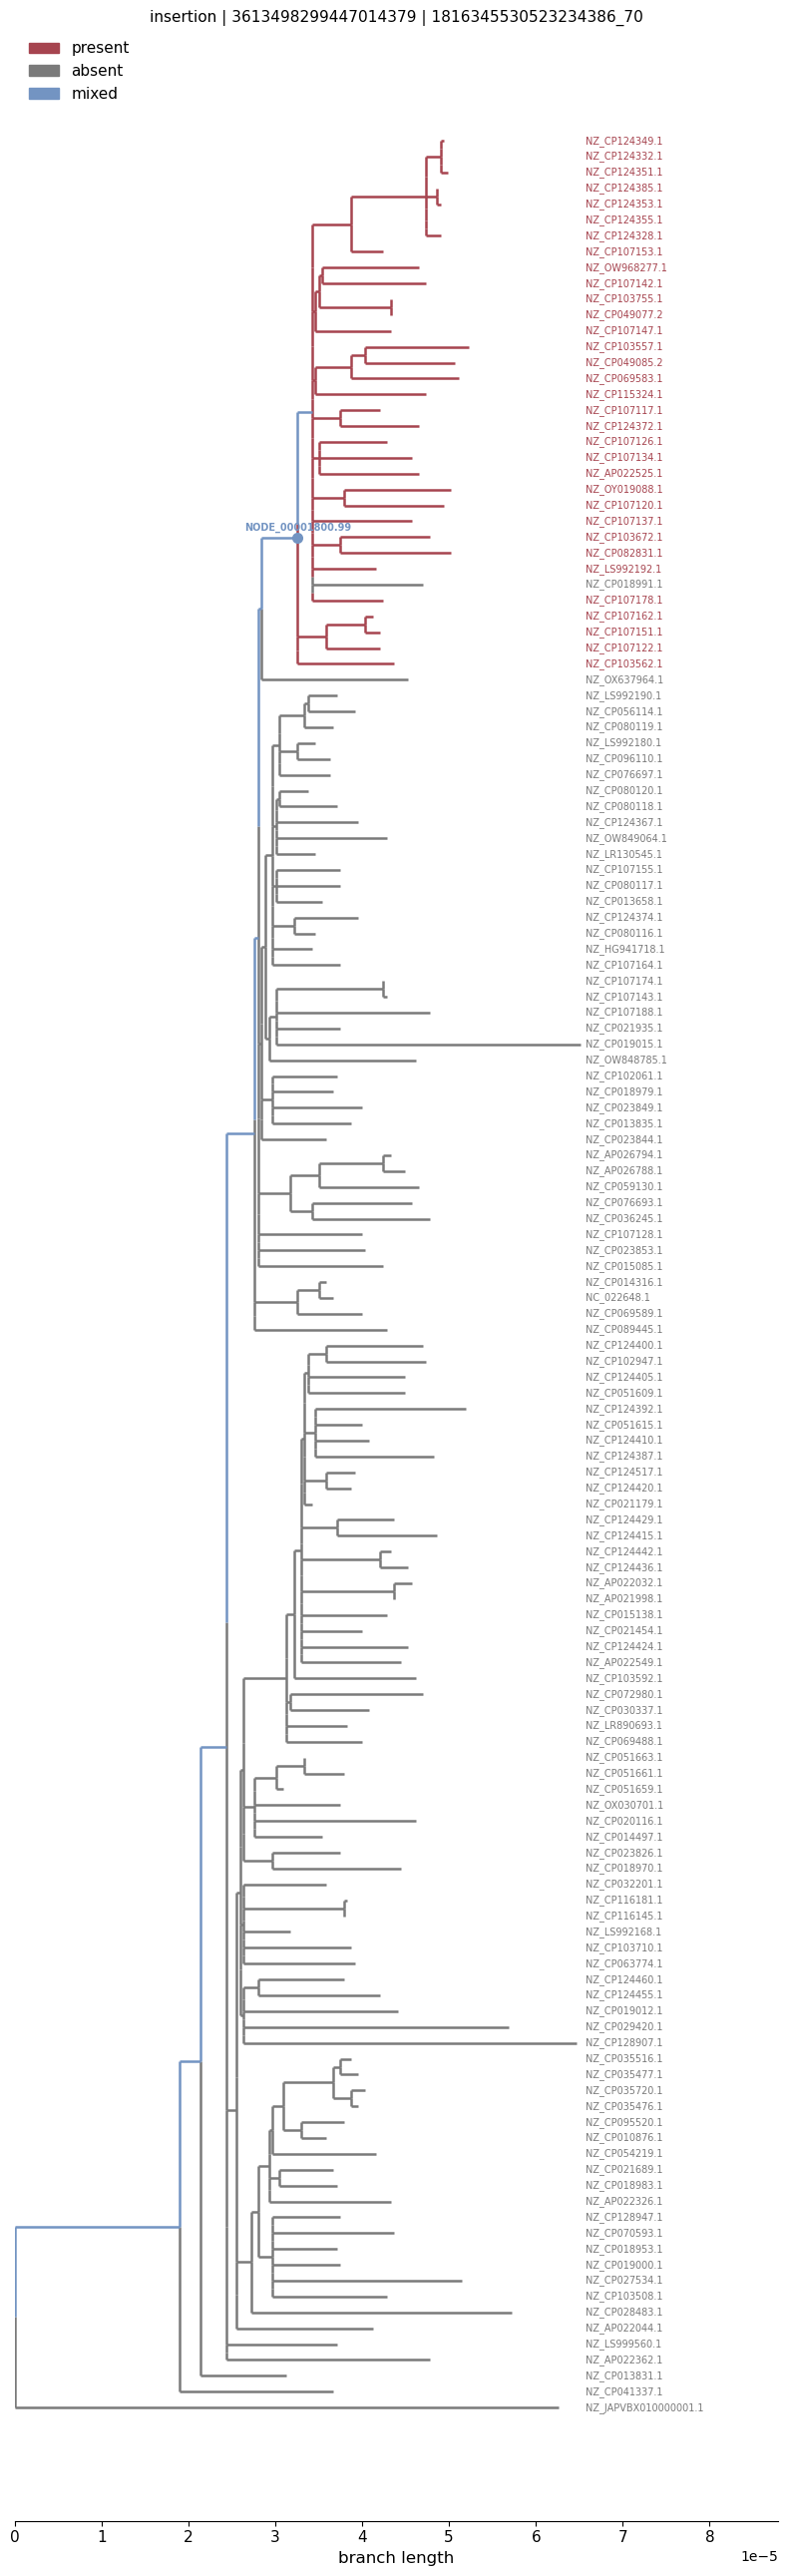

In [15]:
plot_event_tree(
      df,
      isolates_1,
      block_id=139818706072034984,
      event_type="insertion",
      context="1816345530523234386_70",
      clade_df=deduplicated_df,
  )

plot_event_tree(
      df,
      isolates_1,
      block_id=3613498299447014379,
      event_type="insertion",
      context="1816345530523234386_70",
      clade_df=deduplicated_df,
  )

## Problems from splitting blocks
- for 3226134370544314880, 17141892380880723886 it happens whenever there are two versions in general, even if there is only one version per cluster

- 3226134370544314880

- 17141892380880723886: the only real alternative block is in NZ_CP021207.1 (branch length 0.0922), all others don't distinguish duplicates and are unlikely to be seperate blocks (branch lengths <= 0.0022)
    - one isolate with many mutations: different block, should be seperated but also not too bad if it isn't (its part of long insertion)
    - 2 appearances of the same block in the same isolate with the same two nucleotide (next to each other) mutation and one occurence having a second 3 Snp, 2 gap mutation (but we are ignoring gaps)
        - the first occurence is the one that technically is at the right position but does have the additional mutation
        - we probably don't want to detect this as a difference
        - copying of IS could have let to mutation
    - NZ_CP051659.1 has also 2 SNPs in its first occurence and not in the duplicated one, NZ_CP051661.1 and NZ_CP051663.1 have the same duplication but not SNPs in the first occurence
    - 1 SNP position that is part of 70% of isolates
        - on consensus 1 - consensus 6 split
    - JAPVB... has translocation and 2 SNPs

- 10854782652321820035:
    - no problem at the borders

Should we be ignoring gaps in block alignments to seperate blocks within the alignment or only at the borders?

## Analyze branch length distribution

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:4049: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



Saved figure to ../figures/branch_length_cutoff.pdf


/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:4049: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



Saved figure to ../figures/branch_length_cutoff.pdf


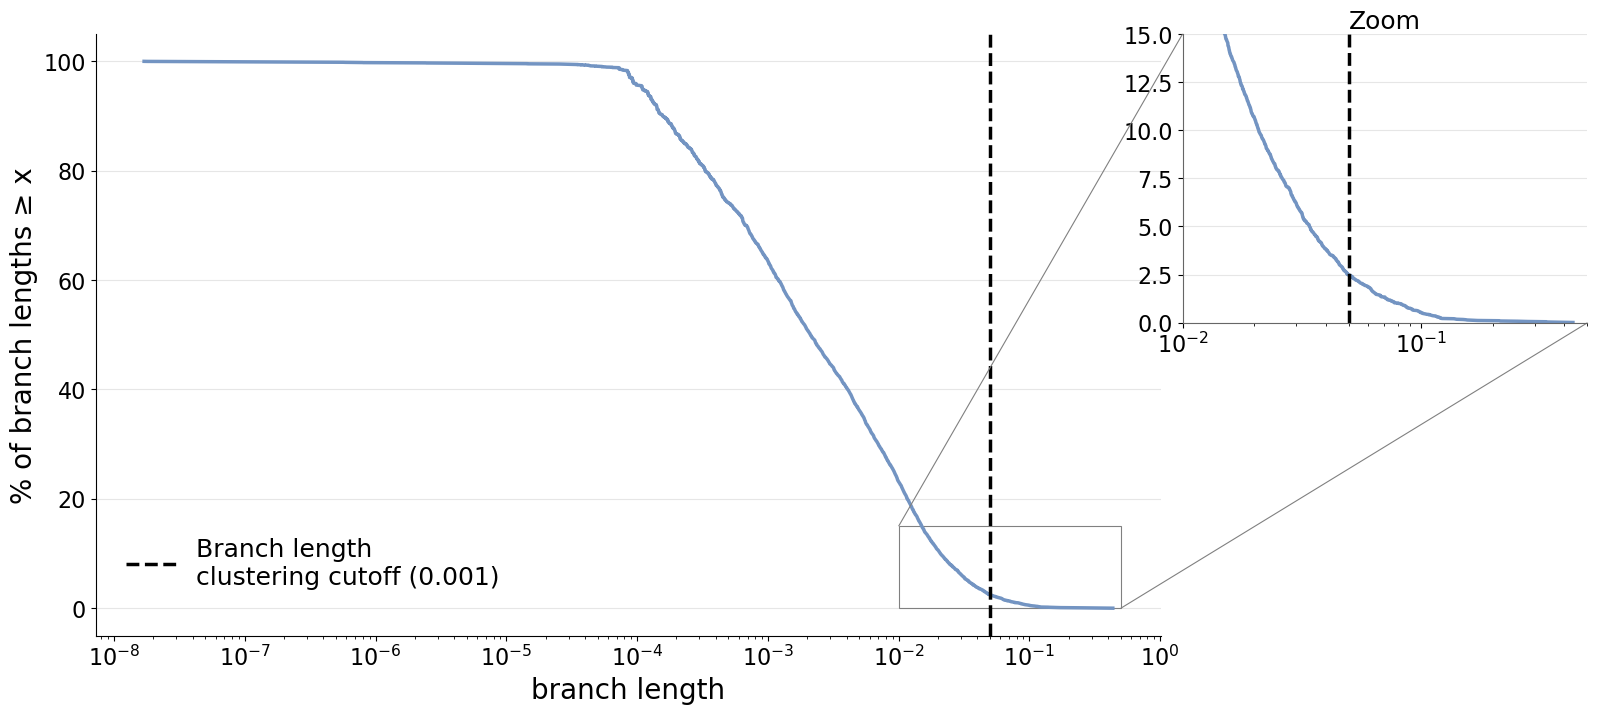

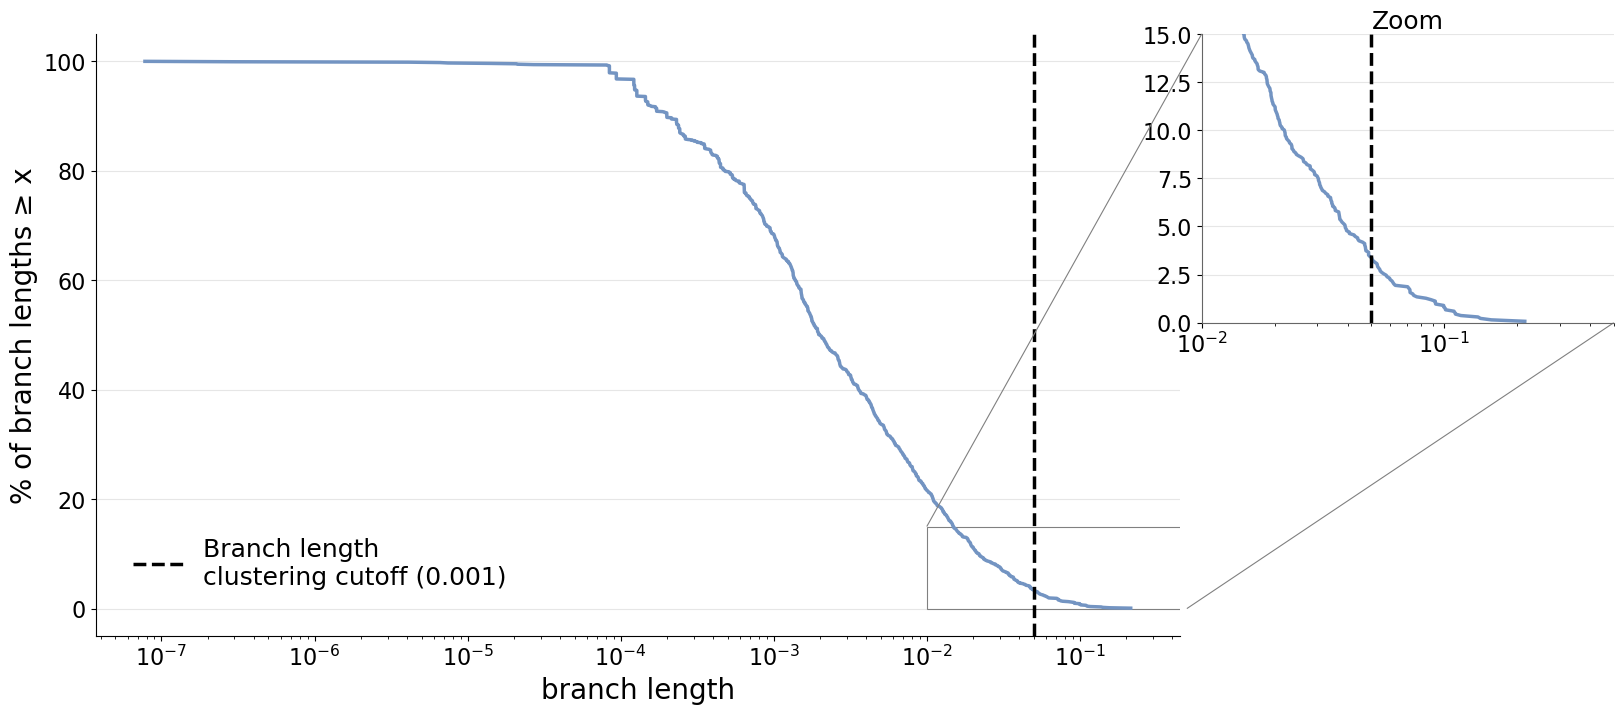

In [13]:
block_bl_df = collect_all_block_branch_lengths("../results/", save_path="../results/consensus_analysis/block_branch_lengths.csv")
bl_cutoff = 0.05

plot_all_junctions_pairwise_distances_zoom(
    distances_df=block_bl_df[~block_bl_df['core'] & (block_bl_df['branch_length'] > 1e-8)],
    distance_col='branch_length',
    cumulative=True,
    percentage=True,
    log_x=True,
    vline=bl_cutoff,
    figsize=(12, 7),
    title="",
    xlabel="branch length",
    ylabel="% of branch lengths ≥ x",
    legend_title="Branch length \nclustering cutoff (0.001)",
    zoom_xlim=(1e-2, 5e-1),
    zoom_ylim=(0, 15),
    save_path="../figures/branch_length_cutoff.pdf"
)

plot_all_junctions_pairwise_distances_zoom(
    distances_df=block_bl_df[block_bl_df['duplicated'] & (block_bl_df['branch_length'] > 1e-8)],
    distance_col='branch_length',
    cumulative=True,
    percentage=True,
    log_x=True,
    vline=bl_cutoff,
    figsize=(12, 7),
    title="",
    xlabel="branch length",
    ylabel="% of branch lengths ≥ x",
    legend_title="Branch length \nclustering cutoff (0.001)",
    zoom_xlim=(1e-2, 5e-1),
    zoom_ylim=(0, 15),
    save_path="../figures/branch_length_cutoff.pdf"
)

## New algorithm that refines current one

Skipping core: FASTA, alignment and tree already exist in /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/consensus_analysis/RYYAQMEJGY_r__ZTHKZYHPIX_f
Processing cluster 0 with 144 isolates
Filtered 14 low-anchor outliers: ['NC_022648.1', 'NZ_AP022044.1', 'NZ_CP010876.1', 'NZ_CP018953.1', 'NZ_CP018983.1', 'NZ_CP019012.1', 'NZ_CP035476.1', 'NZ_CP035720.1', 'NZ_CP080118.1', 'NZ_CP095520.1', 'NZ_CP096110.1', 'NZ_CP103562.1', 'NZ_CP124392.1', 'NZ_CP124460.1']


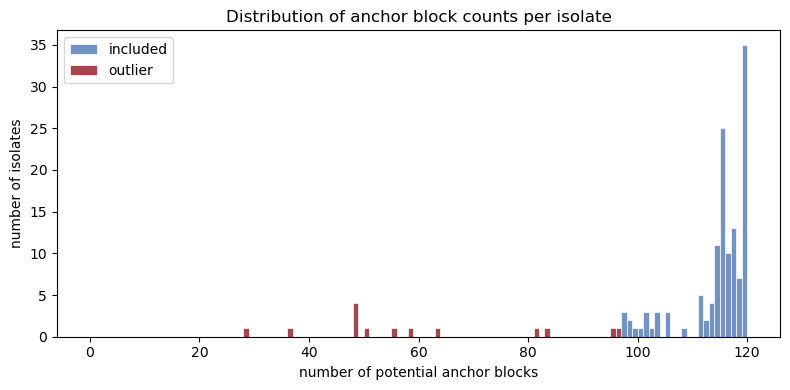

Block 13612719202651021848 ctx=17152770097337652971_1 only appeared once in cluster. Assuming gain with ancestral state 0.
Block 3226134370544314880_0 ctx=17152770097337652971_1 only appeared once in cluster. Assuming gain with ancestral state 0.
Block 17141892380880723886 ctx=17152770097337652971_1 only appeared once in cluster. Assuming gain with ancestral state 0.
Block 16424442392483324144 ctx=17152770097337652971_1 only appeared once in cluster. Assuming gain with ancestral state 0.


In [4]:
junction_name = "RYYAQMEJGY_r__ZTHKZYHPIX_f"
pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_name}.json")

# define paths based on edges
path_dict = pangraph.to_path_dictionary()
path_dict = {isolate: pu.Path.from_tuple_list(path, 'node') for isolate, path in path_dict.items()}

# add node ids
for isolate, path in path_dict.items():
    for idx, node in enumerate(path.nodes):
        node.nid = pangraph.paths[isolate].nodes[idx]

path_dict = deduplicate_blocks_by_sequence(pangraph, path_dict, junction_name, length_threshold=0.1)

cluster_map, cluster_to_isos, _, _ = cluster_isolates_by_core_blocks(pangraph, path_dict, junction_name, clustering_bl_thresh=0.001)

tree_path = "../config/polished_tree.nwk"
tree = Phylo.read(tree_path, "newick")
tree.rooted = True
consensus_paths = {}

for cl, isolate_list in cluster_to_isos.items():
    path_dict_cluster = {iso: path_dict[iso] for iso in isolate_list}
    print(f"Processing cluster {cl} with {len(isolate_list)} isolates")
    isolate_list = filter_isolates_by_anchor_count(path_dict_cluster, rare_context_thresh=0.2, z_score_threshold=3.5, verbose = True)
    path_dict_cluster = {iso: path_dict_cluster[iso] for iso in isolate_list}
    path_dict_cluster_dedup, freq_cluster, cluster_dedup_stats = rededuplicate_cluster_paths(path_dict_cluster, rare_context_thresh=0.2)

    blocks, block2idx = build_block_index(path_dict_cluster_dedup, strand_sensitive=False)
    binary_encodings = encode_paths_binary(path_dict_cluster_dedup, block2idx, strand_sensitive=False)

    subtree = build_subtree(tree, isolate_list)

    fitch_ancestral_reconstruction(subtree, binary_encodings)
    root_states = subtree.root._state_sets

    #ambiguous_blocks = [block for block, state in zip(blocks, root_states) if len(state) > 1]
    #create_block_msas_for_cluster(junction_name, isolate_list, cl, ambiguous_blocks,
    #                              path_dict_cluster_dedup=path_dict_cluster_dedup)
    #df, pair_dists = summarize_block_msas(junction_name, cl, return_pairwise_dists=True, context_sensitive=True)

    root_states_unique, amb_stats = decide_ambiguities(root_states, isolate_list, junction_name, cl, blocks, block2idx, path_dict_cluster_dedup=path_dict_cluster_dedup, individual_gain_thresh=0.001, verbose=None)

    #filter_set = {block for block, state in zip(blocks, root_states_unique) if 0 in state}
    #filtered_cluster_paths = filter_deduplicated_paths(path_dict_cluster_dedup, filter_set, strand_sensitive=False)
    #consensus_path = compute_majority_path(filtered_cluster_paths)
    #consensus_path = remap_consensus_to_global_contexts(consensus_path, filtered_cluster_paths, path_dict_cluster_dedup, path_dict)

    #consensus_paths[cl] = consensus_path
    break

#consensus_paths_plotting, assignment_df_plotting, _ = consensus_paths_and_assignments(consensus_paths, cluster_map)



In [6]:
for isolate, path in path_dict_cluster_dedup.items():
    for node in path.nodes:
        if type(node.id) == str:
            print(node)

[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|+|5475115445007176344_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|+|6912564871896832629_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|7385292223686217602_1]
[3226134370544314880_0|-|104904607409295

In [7]:
from collections import Counter
block_occurences = Counter()

for isolate, path in path_dict_cluster_dedup.items():
    for node in path.nodes:
        if node.id == "3226134370544314880_0":
            block_occurences[node] += 1

In [8]:
block_occurences

Counter({[3226134370544314880_0|-|7385292223686217602_1]: 129,
         [3226134370544314880_0|+|5475115445007176344_1]: 3,
         [3226134370544314880_0|-|10490460740929557719_1]: 3,
         [3226134370544314880_0|-|9350095107367691978_1]: 3,
         [3226134370544314880_0|-|5475115445007176344_1]: 2,
         [3226134370544314880_0|+|6912564871896832629_1]: 1,
         [3226134370544314880_0|-|10854782652321820035_1]: 1,
         [3226134370544314880_0|+|2089333824671448751_1]: 1,
         [3226134370544314880_0|-|12363789723620449651_1]: 1,
         [3226134370544314880_0|+|441542311555414356_1]: 1,
         [3226134370544314880_0|+|14706321765832802919_1]: 1,
         [3226134370544314880_0|-|18081619434129753211_1]: 1,
         [3226134370544314880_0|-|17152770097337652971_1]: 1})

In [55]:
# 0.2
block_occurences

Counter({[3226134370544314880|-|7385292223686217602_1]: 129,
         [3226134370544314880|+|5475115445007176344_1]: 3,
         [3226134370544314880|-|10490460740929557719_1]: 3,
         [3226134370544314880|-|9350095107367691978_1]: 3,
         [3226134370544314880|-|5475115445007176344_1]: 2,
         [3226134370544314880|+|6912564871896832629_1]: 1,
         [3226134370544314880|-|10854782652321820035_1]: 1,
         [3226134370544314880|+|2089333824671448751_1]: 1,
         [3226134370544314880|-|12363789723620449651_1]: 1,
         [3226134370544314880|+|441542311555414356_1]: 1,
         [3226134370544314880|+|14706321765832802919_1]: 1,
         [3226134370544314880|-|18081619434129753211_1]: 1,
         [3226134370544314880|-|17152770097337652971_1]: 1})

In [60]:
# 0.1

block_occurences

Counter({[3226134370544314880_0|-|7385292223686217602_1]: 129,
         [3226134370544314880_0|+|5475115445007176344_1]: 3,
         [3226134370544314880_0|-|10490460740929557719_1]: 3,
         [3226134370544314880_0|-|9350095107367691978_1]: 3,
         [3226134370544314880_0|-|5475115445007176344_1]: 2,
         [3226134370544314880_0|+|6912564871896832629_1]: 1,
         [3226134370544314880_0|-|10854782652321820035_1]: 1,
         [3226134370544314880_0|+|2089333824671448751_1]: 1,
         [3226134370544314880_0|-|12363789723620449651_1]: 1,
         [3226134370544314880_0|+|441542311555414356_1]: 1,
         [3226134370544314880_0|+|14706321765832802919_1]: 1,
         [3226134370544314880_0|-|18081619434129753211_1]: 1,
         [3226134370544314880_0|-|17152770097337652971_1]: 1})

In [12]:
path_dict["NZ_AP022362.1"]

[16671105780806995519|+]_[10958655627444534111|+]_[3419103275029521940|+]_[1448964389002043948|+]_[7166485448600219032|+]_[10480880799551222441|+]_[9943278599560102111|+]_[7385292223686217602|+]_[13612719202651021848|-]_[3226134370544314880_0|-]_[17141892380880723886_0|-]_[16424442392483324144|-]_[6800119766726695319|+]_[5670023643096029701_1|+]_[11734174143264340999_0|+]_[14230977707636736595|+]_[15169038317952353904|+]_[6912564871896832629|+]_[1833494430068775247|+]_[441542311555414356|+]_[578008595963632427|+]_[13050355685719842709|+]_[16400092613407614919|+]_[5598563553016563611|+]_[6523613490405440663|+]_[5285753434584984164|-]_[11300668210740262185|-]_[5339633743814445085|-]_[13388509215143776072|-]_[7110182631703495678|+]_[951767945673275678|+]_[8987038859492738001_0|+]_[15360012090594632702|+]_[8530574476422229527|+]_[12363789723620449651_0|+]_[3925988953842971952_0|+]_[11989555523476015498|+]_[8828234920825701013|+]_[9664989659593652885|+]_[1377680073246787056_0|+]_[9335326342

In [24]:
junction_name = "RYYAQMEJGY_r__ZTHKZYHPIX_f"
pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_name}.json")
tree_path = "../config/polished_tree.nwk"

cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, *_ = find_consensus_paths_refined(
            junction_name,
            clustering_bl_thresh=0.001,
            tree_path=str(tree_path),
            rare_context_thresh=0.2, z_score_threshold=3.5, seq_dedup_length_threshold=0.2
        )

Skipping core: FASTA, alignment and tree already exist in /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/consensus_analysis/RYYAQMEJGY_r__ZTHKZYHPIX_f
Filtered 14 low-anchor outliers: ['NC_022648.1', 'NZ_AP022044.1', 'NZ_CP010876.1', 'NZ_CP018953.1', 'NZ_CP018983.1', 'NZ_CP019012.1', 'NZ_CP035476.1', 'NZ_CP035720.1', 'NZ_CP080118.1', 'NZ_CP095520.1', 'NZ_CP096110.1', 'NZ_CP103562.1', 'NZ_CP124392.1', 'NZ_CP124460.1']
Block 13612719202651021848 ctx=17152770097337652971_1 only appeared once in cluster. Assuming gain with ancestral state 0.
Block 3226134370544314880 ctx=17152770097337652971_1 only appeared once in cluster. Assuming gain with ancestral state 0.
Block 17141892380880723886 ctx=17152770097337652971_1 only appeared once in cluster. Assuming gain with ancestral state 0.
Block 16424442392483324144 ctx=17152770097337652971_1 only appeared once in cluster. Assuming gain with ancestral state 0.
44 / 130 isolates share the majority path
No ambiguous blocks

In [9]:
path_dict["NZ_AP022362.1"]

[16671105780806995519|+|]_[10958655627444534111|+|]_[3419103275029521940|+|]_[1448964389002043948|+|]_[7166485448600219032|+|]_[10480880799551222441|+|]_[9943278599560102111|+|]_[7385292223686217602|+|]_[13612719202651021848|-|7385292223686217602_1]_[3226134370544314880_0|-|7385292223686217602_1]_[17141892380880723886|-|7385292223686217602_1]_[16424442392483324144|-|7385292223686217602_1]_[6800119766726695319|+|7385292223686217602_1]_[5670023643096029701|+|7385292223686217602_1]_[11734174143264340999|+|7385292223686217602_1]_[14230977707636736595|+|7385292223686217602_1]_[15169038317952353904|+|7385292223686217602_1]_[6912564871896832629|+|7385292223686217602_1]_[1833494430068775247|+|7385292223686217602_1]_[441542311555414356|+|7385292223686217602_1]_[578008595963632427|+|7385292223686217602_1]_[13050355685719842709|+|7385292223686217602_1]_[16400092613407614919|+|7385292223686217602_1]_[5598563553016563611|+|7385292223686217602_1]_[6523613490405440663|+|7385292223686217602_1]_[528575

In [7]:
path_dict["NZ_CP128947.1"]

[16671105780806995519|+|]_[10958655627444534111|+|]_[3419103275029521940|+|]_[1448964389002043948|+|]_[7166485448600219032|+|]_[10480880799551222441|+|]_[9943278599560102111|+|]_[7385292223686217602|+|]_[13612719202651021848|-|7385292223686217602_1]_[3226134370544314880_0|-|7385292223686217602_1]_[17141892380880723886|-|7385292223686217602_1]_[16424442392483324144|-|7385292223686217602_1]_[6800119766726695319|+|7385292223686217602_1]_[5670023643096029701|+|7385292223686217602_1]_[11734174143264340999|+|7385292223686217602_1]_[14230977707636736595|+|7385292223686217602_1]_[15169038317952353904|+|7385292223686217602_1]_[6912564871896832629|+|7385292223686217602_1]_[1833494430068775247|+|7385292223686217602_1]_[441542311555414356|+|7385292223686217602_1]_[578008595963632427|+|7385292223686217602_1]_[13050355685719842709|+|7385292223686217602_1]_[16400092613407614919|+|7385292223686217602_1]_[5598563553016563611|+|7385292223686217602_1]_[6523613490405440663|+|7385292223686217602_1]_[528575

In [8]:
path_dict["NZ_CP021207.1"]

[16671105780806995519|+|]_[3419103275029521940|+|]_[17132749706685761441|+|]_[11568528480701071914|+|]_[2053511391527641179|+|]_[15986652507740091122|+|]_[3613498299447014379|-|]_[5760990709145016390|+|]_[16424442392483324144|+|3419103275029521940_1]_[6864972403499280163|-|]_[17141892380880723886|+|3419103275029521940_1]_[3226134370544314880_1|+|]_[3873233606715849281|+|]_[13388509215143776072|-|3419103275029521940_1]_[7110182631703495678|+|3419103275029521940_1]_[951767945673275678|+|3419103275029521940_1]_[8987038859492738001|+|3419103275029521940_1]_[15640169070930962254|+|]_[16795043980430484644|+|]_[2031366472340085717|+|]_[7652900878506180787|+|]_[8323931406784048664|+|]_[14402806192630103767|+|]_[8948595421902822096|+|]_[10783653725007775588|+|3419103275029521940_1]_[15640176264655488742|+|3419103275029521940_1]_[16682535971851667967|+|3419103275029521940_1]_[17789862543328019283|+|3419103275029521940_1]_[9661425280189610721|+|3419103275029521940_1]_[10490460740929557719|+|34191

In [5]:
consensus_paths_core[0]

[16671105780806995519|+|]_[10958655627444534111|+|]_[3419103275029521940|+|]_[1448964389002043948|+|]_[7166485448600219032|+|]_[10480880799551222441|+|]_[9943278599560102111|+|]_[7385292223686217602|+|]_[13612719202651021848|-|7385292223686217602_1]_[3226134370544314880|-|7385292223686217602_1]_[17141892380880723886|-|7385292223686217602_1]_[16424442392483324144|-|7385292223686217602_1]_[6800119766726695319|+|7385292223686217602_1]_[5670023643096029701|+|7385292223686217602_1]_[11734174143264340999|+|7385292223686217602_1]_[14230977707636736595|+|7385292223686217602_1]_[15169038317952353904|+|7385292223686217602_1]_[6912564871896832629|+|7385292223686217602_1]_[1833494430068775247|+|7385292223686217602_1]_[441542311555414356|+|7385292223686217602_1]_[578008595963632427|+|7385292223686217602_1]_[13050355685719842709|+|7385292223686217602_1]_[16400092613407614919|+|7385292223686217602_1]_[5598563553016563611|+|7385292223686217602_1]_[6523613490405440663|+|7385292223686217602_1]_[52857534

[16671105780806995519|+|]_[10958655627444534111|+|]_[3419103275029521940|+|]_[1448964389002043948|+|]_[7166485448600219032|+|]_[10480880799551222441|+|]_[9943278599560102111|+|]_[7385292223686217602|+|]_[13612719202651021848|-|7385292223686217602_1]_[3226134370544314880|-|7385292223686217602_1]_[17141892380880723886|-|7385292223686217602_1]_[16424442392483324144|-|7385292223686217602_1]_[6800119766726695319|+|7385292223686217602_1]_[5670023643096029701|+|7385292223686217602_1]_[11734174143264340999|+|7385292223686217602_1]_[14230977707636736595|+|7385292223686217602_1]_[15169038317952353904|+|7385292223686217602_1]_[6912564871896832629|+|7385292223686217602_1]_[1833494430068775247|+|7385292223686217602_1]_[441542311555414356|+|7385292223686217602_1]_[578008595963632427|+|7385292223686217602_1]_[13050355685719842709|+|7385292223686217602_1]_[16400092613407614919|+|7385292223686217602_1]_[5598563553016563611|+|7385292223686217602_1]_[6523613490405440663|+|7385292223686217602_1]_[5285753434584984164|-|7385292223686217602_1]_[11300668210740262185|-|7385292223686217602_1]_[5339633743814445085|-|7385292223686217602_1]_[13388509215143776072|-|7385292223686217602_1]_[7110182631703495678|+|7385292223686217602_1]_[951767945673275678|+|7385292223686217602_1]_[8987038859492738001|+|7385292223686217602_1]_[15360012090594632702|+|7385292223686217602_1]_[8530574476422229527|+|7385292223686217602_1]_[12363789723620449651|+|7385292223686217602_1]_[3925988953842971952|+|7385292223686217602_1]_[11989555523476015498|+|7385292223686217602_1]_[8828234920825701013|+|7385292223686217602_1]_[9664989659593652885|+|7385292223686217602_1]_[1377680073246787056|+|7385292223686217602_1]_[9335326342918343692|+|7385292223686217602_1]_[1518932996109400524|+|7385292223686217602_1]_[9763119427097469072|+|7385292223686217602_1]_[3545852064258964763|+|7385292223686217602_1]_[8053956808185496261|+|7385292223686217602_1]_[10854782652321820035|+|7385292223686217602_1]_[11745729991170220670|+|7385292223686217602_1]_[18081619434129753211|+|7385292223686217602_1]_[14706321765832802919|+|7385292223686217602_1]_[3572206297778278323|+|7385292223686217602_1]_[10933325453849816616|+|7385292223686217602_1]_[2793330396965050145|+|7385292223686217602_1]_[10347546412604617089|+|7385292223686217602_1]_[4508845066497308247|+|7385292223686217602_1]_[11077888829420032469|+|7385292223686217602_1]_[648713480049732840|+|7385292223686217602_1]_[3621101531925085054|+|7385292223686217602_1]_[10783653725007775588|+|7385292223686217602_1]_[15640176264655488742|+|7385292223686217602_1]_[16682535971851667967|+|7385292223686217602_1]_[17789862543328019283|+|7385292223686217602_1]_[2089333824671448751|+|7385292223686217602_1]_[9661425280189610721|+|7385292223686217602_1]_[10490460740929557719|+|7385292223686217602_1]_[13125551893097988568|+|7385292223686217602_1]_[12885162208417639662|+|7385292223686217602_1]_[10401150471569339000|+|7385292223686217602_1]_[15911069344949453994|+|7385292223686217602_1]_[9350095107367691978|+|7385292223686217602_1]_[510116479221794419|+|7385292223686217602_1]_[1816345530523234386|+|]_[17152770097337652971|+|]_[4599771409276432276|+|]_[3444509637410765656|+|]_[12922793938882367282|+|]_[6010508614880330566|+|]_[7056737478235582250|+|]_[4115339216812906783|+|]_[3625178616324588497|+|]_[12816642360197487349|+|]_[8700310286043965830|+|]_[9793083189342278796|+|]_[601825595835453317|+|]_[9674778679006637834|+|]_[13947990288566045354|+|]_[9081924950530700319|+|]_[5475115445007176344|+|]_[1677175234433554216|+|]_[16984773584921162349|+|]_[10920548072615866511|+|]_[13401516282804455284|+|]_[17897566196295069196|+|]_[12204945321609100045|+|]_[6376021195701232625|+|]_[4337683814885600261|+|]_[6698635406820396402|+|]_[8748029925198249866|+|]_[12487832503496394897|+|]_[8489570333192664224|+|]_[17827728088232699742|+|]_[13388509215143776072|+|7385292223686217602_2]_[5339633743814445085|+|7385292223686217602_2]_[11300668210740262185|+|7385292223686217602_2]_[5285753434584984164|+|7385292223686217602_2]_[8843624255696360543|+|7385292223686217602_1]_[4892779445509988905|+|7385292223686217602_1]_[1962573528736087556|+|]_[6362012061147730151|+|]_[18336865242387238343|+|]_[6614051743088206966|+|]_[4975549513306979906|+|]_[4865255762798348422|+|]_[4839204682227131484|+|]_[3043516895904981143|+|]_[8895753346499007854|+|]_[3592225432955686682|+|]_[15214930222195849744|+|]_[13441773807216920667|+|]_[2632449877243298885|+|]_[14530442464259238252|+|]_[14389456323479374036|+|]_[4533616026087082371|+|]_[122115647818668942|+|]_[18146406109094649449|+|]

[16671105780806995519|+|]_[10958655627444534111|+|]_[3419103275029521940|+|]_[1448964389002043948|+|]_[7166485448600219032|+|]_[10480880799551222441|+|]_[9943278599560102111|+|]_[7385292223686217602|+|]_[13612719202651021848|-|7385292223686217602_1]_[3226134370544314880|-|7385292223686217602_1]_[17141892380880723886|-|7385292223686217602_1]_[16424442392483324144|-|7385292223686217602_1]_[6800119766726695319|+|7385292223686217602_1]_[5670023643096029701|+|7385292223686217602_1]_[11734174143264340999|+|7385292223686217602_1]_[14230977707636736595|+|7385292223686217602_1]_[15169038317952353904|+|7385292223686217602_1]_[6912564871896832629|+|7385292223686217602_1]_[1833494430068775247|+|7385292223686217602_1]_[441542311555414356|+|7385292223686217602_1]_[578008595963632427|+|7385292223686217602_1]_[13050355685719842709|+|7385292223686217602_1]_[16400092613407614919|+|7385292223686217602_1]_[5598563553016563611|+|7385292223686217602_1]_[6523613490405440663|+|7385292223686217602_1]_[5285753434584984164|-|7385292223686217602_1]_[11300668210740262185|-|7385292223686217602_1]_[5339633743814445085|-|7385292223686217602_1]_[13388509215143776072|-|7385292223686217602_1]_[7110182631703495678|+|7385292223686217602_1]_[951767945673275678|+|7385292223686217602_1]_[8987038859492738001|+|7385292223686217602_1]_[15360012090594632702|+|7385292223686217602_1]_[8530574476422229527|+|7385292223686217602_1]_[12363789723620449651|+|7385292223686217602_1]_[3925988953842971952|+|7385292223686217602_1]_[11989555523476015498|+|7385292223686217602_1]_[8828234920825701013|+|7385292223686217602_1]_[9664989659593652885|+|7385292223686217602_1]_[1377680073246787056|+|7385292223686217602_1]_[9335326342918343692|+|7385292223686217602_1]_[1518932996109400524|+|7385292223686217602_1]_[9763119427097469072|+|7385292223686217602_1]_[3545852064258964763|+|7385292223686217602_1]_[8053956808185496261|+|7385292223686217602_1]_[10854782652321820035|+|7385292223686217602_1]_[11745729991170220670|+|7385292223686217602_1]_[18081619434129753211|+|7385292223686217602_1]_[14706321765832802919|+|7385292223686217602_1]_[3572206297778278323|+|7385292223686217602_1]_[10933325453849816616|+|7385292223686217602_1]_[2793330396965050145|+|7385292223686217602_1]_[10347546412604617089|+|7385292223686217602_1]_[4508845066497308247|+|7385292223686217602_1]_[11077888829420032469|+|7385292223686217602_1]_[648713480049732840|+|7385292223686217602_1]_[3621101531925085054|+|7385292223686217602_1]_[10783653725007775588|+|7385292223686217602_1]_[15640176264655488742|+|7385292223686217602_1]_[16682535971851667967|+|7385292223686217602_1]_[17789862543328019283|+|7385292223686217602_1]_[2089333824671448751|+|7385292223686217602_1]_[9661425280189610721|+|7385292223686217602_1]_[10490460740929557719|+|7385292223686217602_1]_[13125551893097988568|+|7385292223686217602_1]_[12885162208417639662|+|7385292223686217602_1]_[10401150471569339000|+|7385292223686217602_1]_[15911069344949453994|+|7385292223686217602_1]_[9350095107367691978|+|7385292223686217602_1]_[510116479221794419|+|7385292223686217602_1]_[1816345530523234386|+|]_[17152770097337652971|+|]_[4599771409276432276|+|]_[3444509637410765656|+|]_[12922793938882367282|+|]_[6010508614880330566|+|]_[7056737478235582250|+|]_[4115339216812906783|+|]_[3625178616324588497|+|]_[12816642360197487349|+|]_[8700310286043965830|+|]_[9793083189342278796|+|]_[601825595835453317|+|]_[9674778679006637834|+|]_[13947990288566045354|+|]_[9081924950530700319|+|]_[5475115445007176344|+|]_[1677175234433554216|+|]_[16984773584921162349|+|]_[10920548072615866511|+|]_[13401516282804455284|+|]_[17897566196295069196|+|]_[12204945321609100045|+|]_[6376021195701232625|+|]_[4337683814885600261|+|]_[6698635406820396402|+|]_[8748029925198249866|+|]_[12487832503496394897|+|]_[8489570333192664224|+|]_[17827728088232699742|+|]_[13388509215143776072|+|7385292223686217602_2]_[5339633743814445085|+|7385292223686217602_2]_[11300668210740262185|+|7385292223686217602_2]_[5285753434584984164|+|7385292223686217602_2]_[8843624255696360543|+|7385292223686217602_1]_[4892779445509988905|+|7385292223686217602_1]_[1962573528736087556|+|]_[6362012061147730151|+|]_[18336865242387238343|+|]_[6614051743088206966|+|]_[4975549513306979906|+|]_[4865255762798348422|+|]_[4839204682227131484|+|]_[3043516895904981143|+|]_[8895753346499007854|+|]_[3592225432955686682|+|]_[15214930222195849744|+|]_[13441773807216920667|+|]_[2632449877243298885|+|]_[14530442464259238252|+|]_[14389456323479374036|+|]_[4533616026087082371|+|]_[122115647818668942|+|]_[18146406109094649449|+|]

[16671105780806995519|+|]_[10958655627444534111|+|]_[3419103275029521940|+|]_[1448964389002043948|+|]_[7166485448600219032|+|]_[10480880799551222441|+|]_[9943278599560102111|+|]_[7385292223686217602|+|]_[13612719202651021848|-|7385292223686217602_1]_[16424442392483324144|-|7385292223686217602_1]_[6800119766726695319|+|7385292223686217602_1]_[5670023643096029701_1|+|7385292223686217602_1]_[11734174143264340999_0|+|7385292223686217602_1]_[14230977707636736595|+|7385292223686217602_1]_[15169038317952353904|+|7385292223686217602_1]_[6912564871896832629|+|7385292223686217602_1]_[1833494430068775247|+|7385292223686217602_1]_[441542311555414356|+|7385292223686217602_1]_[578008595963632427|+|7385292223686217602_1]_[13050355685719842709|+|7385292223686217602_1]_[16400092613407614919|+|7385292223686217602_1]_[5598563553016563611|+|7385292223686217602_1]_[6523613490405440663|+|7385292223686217602_1]_[5285753434584984164|-|7385292223686217602_1]_[11300668210740262185|-|7385292223686217602_1]_[5339633743814445085|-|7385292223686217602_1]_[13388509215143776072|-|7385292223686217602_1]_[7110182631703495678|+|7385292223686217602_1]_[951767945673275678|+|7385292223686217602_1]_[8987038859492738001_0|+|7385292223686217602_1]_[15360012090594632702|+|7385292223686217602_1]_[8530574476422229527|+|7385292223686217602_1]_[12363789723620449651_0|+|7385292223686217602_1]_[3925988953842971952_0|+|7385292223686217602_1]_[11989555523476015498|+|7385292223686217602_1]_[8828234920825701013|+|7385292223686217602_1]_[9664989659593652885|+|7385292223686217602_1]_[1377680073246787056_0|+|7385292223686217602_1]_[9335326342918343692|+|7385292223686217602_1]_[1518932996109400524|+|7385292223686217602_1]_[9763119427097469072|+|7385292223686217602_1]_[3545852064258964763|+|7385292223686217602_1]_[8053956808185496261|+|7385292223686217602_1]_[10854782652321820035_0|+|7385292223686217602_1]_[11745729991170220670|+|7385292223686217602_1]_[18081619434129753211|+|7385292223686217602_1]_[14706321765832802919|+|7385292223686217602_1]_[3572206297778278323|+|7385292223686217602_1]_[10933325453849816616|+|7385292223686217602_1]_[2793330396965050145|+|7385292223686217602_1]_[10347546412604617089|+|7385292223686217602_1]_[4508845066497308247|+|7385292223686217602_1]_[11077888829420032469|+|7385292223686217602_1]_[648713480049732840|+|7385292223686217602_1]_[3621101531925085054|+|7385292223686217602_1]_[10783653725007775588|+|7385292223686217602_1]_[15640176264655488742|+|7385292223686217602_1]_[16682535971851667967|+|7385292223686217602_1]_[17789862543328019283|+|7385292223686217602_1]_[2089333824671448751|+|7385292223686217602_1]_[9661425280189610721|+|7385292223686217602_1]_[10490460740929557719|+|7385292223686217602_1]_[13125551893097988568|+|7385292223686217602_1]_[12885162208417639662_0|+|7385292223686217602_1]_[10401150471569339000|+|7385292223686217602_1]_[15911069344949453994|+|7385292223686217602_1]_[9350095107367691978|+|7385292223686217602_1]_[510116479221794419_0|+|7385292223686217602_1]_[1816345530523234386|+|]_[17152770097337652971|+|]_[4599771409276432276|+|]_[3444509637410765656|+|]_[12922793938882367282|+|]_[6010508614880330566|+|]_[7056737478235582250|+|]_[4115339216812906783|+|]_[3625178616324588497|+|]_[12816642360197487349|+|]_[8700310286043965830|+|]_[9793083189342278796|+|]_[601825595835453317|+|]_[9674778679006637834|+|]_[13947990288566045354|+|]_[9081924950530700319|+|]_[5475115445007176344|+|]_[1677175234433554216|+|]_[16984773584921162349|+|]_[10920548072615866511|+|]_[13401516282804455284|+|]_[17897566196295069196|+|]_[12204945321609100045|+|]_[6376021195701232625|+|]_[4337683814885600261|+|]_[6698635406820396402|+|]_[8748029925198249866|+|]_[12487832503496394897|+|]_[8489570333192664224|+|]_[17827728088232699742|+|]_[13388509215143776072|+|7385292223686217602_2]_[5339633743814445085|+|7385292223686217602_2]_[11300668210740262185|+|7385292223686217602_2]_[5285753434584984164|+|7385292223686217602_2]_[8843624255696360543|+|7385292223686217602_1]_[4892779445509988905|+|7385292223686217602_1]_[1962573528736087556|+|]_[6362012061147730151|+|]_[18336865242387238343|+|]_[6614051743088206966|+|]_[4975549513306979906|+|]_[4865255762798348422|+|]_[4839204682227131484|+|]_[3043516895904981143|+|]_[8895753346499007854|+|]_[3592225432955686682|+|]_[15214930222195849744|+|]_[13441773807216920667|+|]_[2632449877243298885|+|]_[14530442464259238252|+|]_[14389456323479374036|+|]_[4533616026087082371|+|]_[122115647818668942|+|]_[18146406109094649449|+|]

In [20]:
item = next((x for x in path_dict_cluster_dedup['NZ_CP051659.1'].nodes if x.id == "17141892380880723886_0"), None)

In [23]:
[x.nid for x in path_dict_cluster_dedup['NZ_CP051659.1'].nodes if x.id == "17141892380880723886_0"]

[14192351342295407039, 7800562871400108647]

In [12]:
path_dict_cluster_dedup['NZ_AP022362.1'].nodes[10].nid

17220334622373818273

[16671105780806995519|+|]_[10958655627444534111|+|]_[3419103275029521940|+|]_[1448964389002043948|+|]_[7166485448600219032|+|]_[10480880799551222441|+|]_[9943278599560102111|+|]_[7385292223686217602|+|]_[13612719202651021848|-|7385292223686217602_1]_[3226134370544314880_0|-|7385292223686217602_1]_[17141892380880723886_0|-|7385292223686217602_1]_[16424442392483324144|-|7385292223686217602_1]_[6800119766726695319|+|]_[5670023643096029701_1|+|]_[11734174143264340999_0|+|]_[14230977707636736595|+|]_[15169038317952353904|+|]_[6912564871896832629|+|]_[1833494430068775247|+|]_[441542311555414356_0|+|]_[578008595963632427|+|]_[13050355685719842709_0|+|]_[16400092613407614919|+|]_[5598563553016563611|+|]_[6523613490405440663|+|]_[5285753434584984164|-|6523613490405440663_1]_[11300668210740262185|-|6523613490405440663_1]_[5339633743814445085|-|6523613490405440663_1]_[13388509215143776072|-|6523613490405440663_1]_[7110182631703495678_0|+|]_[951767945673275678|+|]_[8987038859492738001_0|+|]_[15360012090594632702|+|]_[8530574476422229527|+|]_[12363789723620449651_0|+|]_[3925988953842971952_1|+|]_[11989555523476015498|+|]_[8828234920825701013|+|]_[9664989659593652885|+|]_[1377680073246787056_5|+|]_[9335326342918343692|+|]_[1518932996109400524|+|]_[9763119427097469072_3|+|]_[3545852064258964763|+|]_[8053956808185496261|+|]_[10854782652321820035_5|+|]_[11745729991170220670|+|]_[18081619434129753211|+|]_[14706321765832802919|+|]_[3572206297778278323|+|]_[10933325453849816616|+|]_[2793330396965050145|+|]_[10347546412604617089|+|]_[4508845066497308247|+|]_[11077888829420032469|+|]_[648713480049732840|+|]_[3621101531925085054|+|]_[10783653725007775588|+|]_[15640176264655488742|+|]_[16682535971851667967|+|]_[17789862543328019283|+|]_[2089333824671448751|+|]_[9661425280189610721|+|]_[10490460740929557719|+|]_[13125551893097988568|+|]_[12885162208417639662_0|+|]_[3613498299447014379|-|]_[139818706072034984|-|]_[10401150471569339000|+|]_[2150995670991051021|+|]_[15911069344949453994|+|]_[9350095107367691978|+|]_[510116479221794419_0|+|]_[1816345530523234386|+|]_[17152770097337652971|+|]_[4599771409276432276|+|]_[3444509637410765656|+|]_[12922793938882367282|+|]_[6010508614880330566|+|]_[7056737478235582250|+|]_[4115339216812906783|+|]_[3625178616324588497|+|]_[12816642360197487349|+|]_[8700310286043965830|+|]_[9793083189342278796|+|]_[601825595835453317|+|]_[9674778679006637834|+|]_[13947990288566045354|+|]_[9081924950530700319|+|]_[5475115445007176344|+|]_[1677175234433554216|+|]_[16984773584921162349|+|]_[10920548072615866511|+|]_[16424442392483324144|+|5475115445007176344_1]_[17141892380880723886_0|+|5475115445007176344_1]_[3226134370544314880_0|+|5475115445007176344_1]_[13612719202651021848|+|5475115445007176344_1]_[13401516282804455284|+|]_[17897566196295069196|+|]_[12204945321609100045|+|]_[6376021195701232625|+|]_[4337683814885600261|+|]_[6698635406820396402|+|]_[8748029925198249866|+|]_[12487832503496394897|+|]_[8489570333192664224|+|]_[17827728088232699742|+|]_[13388509215143776072|+|5475115445007176344_1]_[5339633743814445085|+|5475115445007176344_1]_[11300668210740262185|+|5475115445007176344_1]_[5285753434584984164|+|5475115445007176344_1]_[8843624255696360543|+|5475115445007176344_1]_[4892779445509988905|+|5475115445007176344_1]_[1962573528736087556|+|]_[6362012061147730151|+|]_[18336865242387238343|+|]_[6614051743088206966|+|]_[4975549513306979906|+|]_[4865255762798348422|+|]_[4839204682227131484|+|]_[3043516895904981143|+|]_[8895753346499007854|+|]_[3592225432955686682|+|]_[15214930222195849744|+|]_[13441773807216920667|+|]_[2632449877243298885|+|]_[14530442464259238252|+|]_[14389456323479374036|+|]_[4533616026087082371|+|]_[122115647818668942|+|]_[18146406109094649449|+|]

Filtered 21 low-anchor outliers: ['NC_022648.1', 'NZ_AP022044.1', 'NZ_CP010876.1', 'NZ_CP018953.1', 'NZ_CP018970.1', 'NZ_CP018983.1', 'NZ_CP019012.1', 'NZ_CP029420.1', 'NZ_CP032201.1', 'NZ_CP035476.1', 'NZ_CP035477.1', 'NZ_CP035516.1', 'NZ_CP035720.1', 'NZ_CP054219.1', 'NZ_CP080118.1', 'NZ_CP095520.1', 'NZ_CP096110.1', 'NZ_CP103562.1', 'NZ_CP124392.1', 'NZ_CP124415.1', 'NZ_CP124460.1']


## Try new algorithm to get consensus path by always considering edges instead of nodes with context

In [6]:
junction_name = "RYYAQMEJGY_r__ZTHKZYHPIX_f"
pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_name}.json")

# define paths based on edges
path_dict = pangraph.to_path_dictionary()
path_dict = {isolate: pu.Path.from_tuple_list(path, 'node') for isolate, path in path_dict.items()}

# add node ids
for isolate, path in path_dict.items():
    for idx, node in enumerate(path.nodes):
        node.nid = pangraph.paths[isolate].nodes[idx]

cluster_map, cluster_to_isos, _, _ = cluster_isolates_by_core_blocks(pangraph, path_dict, junction_name, clustering_bl_thresh=0.001)

edge_path_dict = {isolate: pu.EdgePath.from_path(path) for isolate, path in path_dict.items()}


tree_path = "../config/polished_tree.nwk"
tree = Phylo.read(tree_path, "newick")
tree.rooted = True
consensus_paths = {}

for cl, isolate_list in cluster_to_isos.items():
    edge_path_dict_cluster = {iso: edge_path_dict[iso] for iso in isolate_list if iso in edge_path_dict}
    path_dict_cluster = {iso: path_dict[iso] for iso in isolate_list if iso in path_dict}
            
    edges, edge2idx = build_edge_index(edge_path_dict_cluster)
    binary_encodings = encode_edge_paths_binary(edge_path_dict_cluster, edge2idx)

    subtree = build_subtree(tree, isolate_list)
    fitch_ancestral_reconstruction(subtree, binary_encodings)
    root_states = subtree.root._state_sets  # list of {0}/{1}, one per edge  
    
    filtered_paths = filter_paths_by_edge_presence(                                                                                                   
          path_dict_cluster,
          edge_path_dict_cluster,                                                                                                                       
          edges,
          root_states,                                                                                                                       
          edge2idx,
          junction_name,
          cl,
    )
    consensus_path = compute_majority_path(filtered_paths)
    consensus_paths[cl] = consensus_path

consensus_paths_plotting, assignment_df_plotting, _ = consensus_paths_and_assignments(consensus_paths, cluster_map)
                                                                                                                                                        
fig = plot_junction_pangraph_interactive(
      pangraph,                                                                                                                                         
      show_consensus=True,
      consensus_paths=consensus_paths_plotting,
      assignments=assignment_df_plotting,
      order="tree",
      cluster_map=cluster_map,                                                                                                                     
      )
fig.show()

25 / 144 isolates share the majority path
1 / 1 (single isolate)
1 / 1 (single isolate)
13 / 17 isolates share the majority path
1 / 1 (single isolate)
37 / 52 isolates share the majority path


In [8]:
for i in range(1, len(consensus_paths_plotting) + 1):
    insertions, ambiguous_insertions, deletions, inversions, translocations, context_stats_df = get_insertions_deletions_from_consensus(assignment_df_plotting, consensus_paths_plotting, path_dict, consensus = i)
    break

Insertions:
NZ_CP102061.1 INSERTED: [3613498299447014379|-]_[139818706072034984|-]
NZ_CP102061.1 INSERTED: [2150995670991051021|+]
NZ_CP080116.1 INSERTED: [9498745749412710955|+]
NZ_CP080116.1 INSERTED: [3613498299447014379|-]_[139818706072034984|-]
NZ_CP080116.1 INSERTED: [2150995670991051021|+]
NZ_CP080116.1 INSERTED: [13388509215143776072|+]
NZ_CP080116.1 INSERTED: [5285753434584984164|+]
NZ_CP124517.1 INSERTED: [4892779445509988905|-]_[8843624255696360543|-]_[5285753434584984164|-]_[11300668210740262185|-]_[5339633743814445085|-]_[13388509215143776072|-]
NZ_CP124517.1 INSERTED: [13388509215143776072|+]
NZ_CP124517.1 INSERTED: [5285753434584984164|+]
NZ_CP019015.1 INSERTED: [3613498299447014379|-]_[139818706072034984|-]
NZ_CP019015.1 INSERTED: [2150995670991051021|+]
NZ_CP019015.1 INSERTED: [13388509215143776072|+]
NZ_CP019015.1 INSERTED: [5285753434584984164|+]
NZ_CP018991.1 INSERTED: [17885250183886920782|+]
NZ_CP018991.1 INSERTED: [2150995670991051021|+]
NZ_CP018991.1 INSERTED: [

## Can sequence similarity information help to resolve duplicated blocks?
It can help in some cases, especially if we build trees on all blocks with a length > 500 bp already but it doesnt fully solve the duplication problem.
- the fact that these blocks could be split doesnt necessarily mean that specifically duplicates will be split
- we can't say anything about short blocks and they are the most problematic
- not all long blocks differ enough

In [24]:
records = []
base_dir = "../results/block_alignments"
                                                                                                                                                                                                                                            
for junction in jdf_all['junction_name']:                                                                                                                                                                                                   
    csv_path = os.path.join(base_dir, junction, f"{junction}_alignment_stats.csv")
    if not os.path.exists(csv_path):                                                                                                                                                                                                        
        continue                                                                                                                                                                                                                            
    df = pd.read_csv(csv_path)
    dup = df[df['duplicated'] == True]                                                                                                                                                                                                      
    for _, row in dup.iterrows():
        records.append({
            'junction_name': junction,                                                                                                                                                                                                      
            'block_id': row['block_id'],
            'len': row['len'],                                                                                                                                                                                                              
            'avg_pairwise_dist': row['avg_pairwise_dist'],
        })                                                                                                                                                                                                                                  

summary_df = pd.DataFrame(records)                                                                                                                                                                                                          
summary_df     

,junction_name,block_id,len,avg_pairwise_dist
0,JJRRWBDVGH_f__TFKJQKVUKX_f,1101536001531877591,175,0.055947
1,JJRRWBDVGH_f__TFKJQKVUKX_f,2251987336623189867,100,0.028571
2,JJRRWBDVGH_f__TFKJQKVUKX_f,3132791157853211795,195,0.066330
3,JJRRWBDVGH_f__TFKJQKVUKX_f,3145149207096864253,122,0.029339
4,JJRRWBDVGH_f__TFKJQKVUKX_f,4866283470688286449,119,0.042347
...,...,...,...,...
405,YUOECYBHUS_f__ZTHKZYHPIX_f,1528420688200569391,1912,0.105181
406,YUOECYBHUS_f__ZTHKZYHPIX_f,3870718793672684742,768,0.043194
407,YUOECYBHUS_f__ZTHKZYHPIX_f,3986164421478461937,454,0.000000
408,YUOECYBHUS_f__ZTHKZYHPIX_f,11739289533746856500,793,0.006574


Percentage of duplicated blocks with length < 200: 25.61%
Percentage of duplicated blocks with length < 500: 57.56%
Percentage of duplicated blocks with length < 1000: 78.54%


<Axes: >

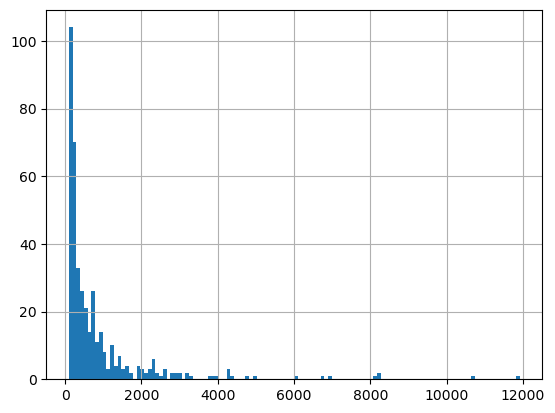

In [20]:
print(f"Percentage of duplicated blocks with length < 200: {len(summary_df[summary_df['len'] < 200]) / len(summary_df) * 100:.2f}%")
print(f"Percentage of duplicated blocks with length < 500: {len(summary_df[summary_df['len'] < 500]) / len(summary_df) * 100:.2f}%")
print(f"Percentage of duplicated blocks with length < 1000: {len(summary_df[summary_df['len'] < 1000]) / len(summary_df) * 100:.2f}%")
summary_df['len'].hist(bins=120)

<Axes: >

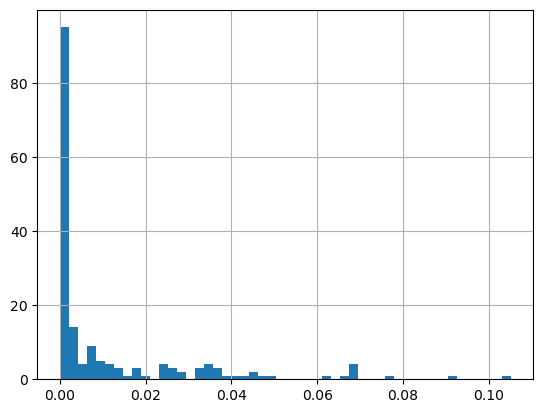

In [16]:
summary_df[summary_df['len'] > 500].avg_pairwise_dist.hist(bins=50)

In [19]:
print(f"{len(summary_df[(summary_df['len'] > 500) & (summary_df['avg_pairwise_dist'] > 0.001)]) / len(summary_df[summary_df['len'] > 500]) * 100:.2f}% of blocks > 500 bp could be split by sequence divergence (avg pairwise dist > 0.001)")
print(f"{len(summary_df[(summary_df['len'] > 1000) & (summary_df['avg_pairwise_dist'] > 0.001)]) / len(summary_df[summary_df['len'] > 1000]) * 100:.2f}% of blocks > 1000 bp could be split by sequence divergence (avg pairwise dist > 0.001)")

54.02% of blocks > 500 bp could be split by sequence divergence (avg pairwise dist > 0.001)
47.73% of blocks > 1000 bp could be split by sequence divergence (avg pairwise dist > 0.001)


Consider all blocks
- if we further split blocks to resolve duplicates we have to also split non-duplicated blocks, this might then just show HR clustering signal or split blocks within clusters
- do we want this complication?

In [27]:
records = []
base_dir = "../results/block_alignments"
                                                                                                                                                                                                                                            
for junction in jdf_all['junction_name']:                                                                                                                                                                                                   
    csv_path = os.path.join(base_dir, junction, f"{junction}_alignment_stats.csv")
    if not os.path.exists(csv_path):                                                                                                                                                                                                        
        continue                                                                                                                                                                                                                            
    df = pd.read_csv(csv_path)
    for _, row in df.iterrows():
        records.append({
            'junction_name': junction,                                                                                                                                                                                                      
            'block_id': row['block_id'],
            'len': row['len'],                                                                                                                                                                                                              
            'avg_pairwise_dist': row['avg_pairwise_dist'],
        })                                                                                                                                                                                                                                  

summary_df_all = pd.DataFrame(records)                                                                                                                                                                                                          
summary_df_all    

,junction_name,block_id,len,avg_pairwise_dist
0,HUTOPWFGVH_f__WJBYSSJHSE_f,4119167410460397689,16280,0.000098
1,HUTOPWFGVH_f__WJBYSSJHSE_f,7811279214181103925,777,0.000000
2,HUTOPWFGVH_f__WJBYSSJHSE_f,8652915928890312090,1698,0.006795
3,HUTOPWFGVH_f__WJBYSSJHSE_f,10223321923686949189,198,0.000000
4,HUTOPWFGVH_f__WJBYSSJHSE_f,11271243518245960494,711,0.000000
...,...,...,...,...
5132,YUOECYBHUS_f__ZTHKZYHPIX_f,15301843099917212677,287,0.000000
5133,YUOECYBHUS_f__ZTHKZYHPIX_f,15685664920164088488,12281,0.000000
5134,YUOECYBHUS_f__ZTHKZYHPIX_f,15870816832931575866,1945,0.000000
5135,YUOECYBHUS_f__ZTHKZYHPIX_f,16141324844737295108,1286,0.069207


Percentage of blocks with length < 200: 10.53%
Percentage of blocks with length < 500: 28.05%
Percentage of blocks with length < 1000: 49.11%


<Axes: >

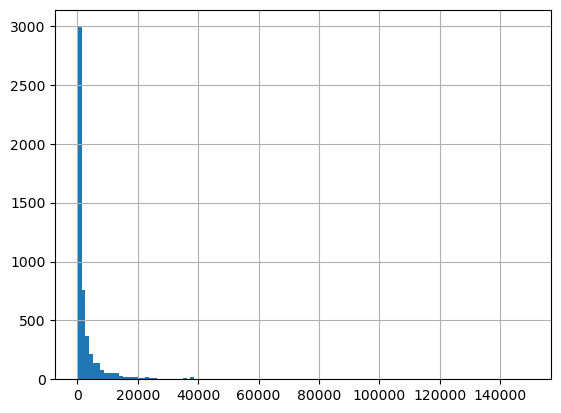

In [30]:
print(f"Percentage of blocks with length < 200: {len(summary_df_all[summary_df_all['len'] < 200]) / len(summary_df_all) * 100:.2f}%")
print(f"Percentage of blocks with length < 500: {len(summary_df_all[summary_df_all['len'] < 500]) / len(summary_df_all) * 100:.2f}%")
print(f"Percentage of blocks with length < 1000: {len(summary_df_all[summary_df_all['len'] < 1000]) / len(summary_df_all) * 100:.2f}%")
summary_df_all['len'].hist(bins=120)

33.49% of blocks > 500 bp could be split by sequence divergence (avg pairwise dist > 0.001)
29.90% of blocks > 1000 bp could be split by sequence divergence (avg pairwise dist > 0.001)


<Axes: >

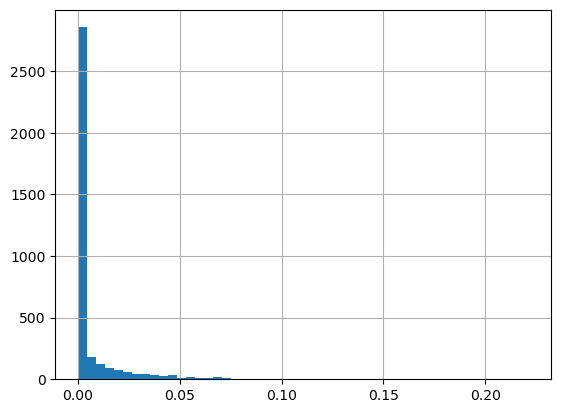

In [32]:
print(f"{len(summary_df_all[(summary_df_all['len'] > 500) & (summary_df_all['avg_pairwise_dist'] > 0.001)]) / len(summary_df_all[summary_df_all['len'] > 500]) * 100:.2f}% of blocks > 500 bp could be split by sequence divergence (avg pairwise dist > 0.001)")
print(f"{len(summary_df_all[(summary_df_all['len'] > 1000) & (summary_df_all['avg_pairwise_dist'] > 0.001)]) / len(summary_df_all[summary_df_all['len'] > 1000]) * 100:.2f}% of blocks > 1000 bp could be split by sequence divergence (avg pairwise dist > 0.001)")

summary_df_all[summary_df_all['len'] > 500].avg_pairwise_dist.hist(bins=50)